In [1]:
import pandas as pd
import numpy as np
df = pd.read_csv("data/telco_customer_churn_raw.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.shape


In [ ]:
df.info()

In [ ]:
df.isnull().sum()

In [ ]:
df["Churn"].value_counts()

In [ ]:
df["Churn"].value_counts(normalize=True)*100

In [2]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"],errors="coerce")
df["TotalCharges"].isnull().sum()    

np.int64(11)

In [3]:
df = df.dropna(subset=["TotalCharges"])
df["TotalCharges"].isnull().sum()

np.int64(0)

In [ ]:
df.shape

In [4]:
df["Churn"] = df["Churn"].map({"Yes":1, "No":0})
df["Churn"].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

In [5]:
churn_rate = df["Churn"].mean()*100
print("Churn Rate:", round(churn_rate,2),"%")

Churn Rate: 26.58 %


In [6]:
contract_churn = df.groupby("Contract")["Churn"].mean().sort_values(ascending=False)
contract_churn

Contract
Month-to-month    0.427097
One year          0.112772
Two year          0.028487
Name: Churn, dtype: float64

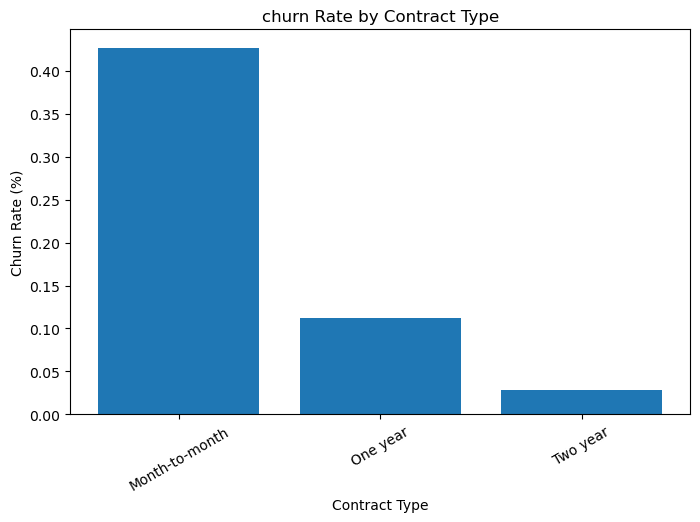

In [7]:
import matplotlib.pyplot as plt
contract_churn = df.groupby("Contract")["Churn"].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))
plt.bar(contract_churn.index, contract_churn.values)
plt.title("churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=30)
plt.show()

In [8]:
tenure_churn = df.groupby("tenure")["Churn"].mean().reset_index()*100
tenure_churn.head()

,tenure,Churn
0,100,61.990212
1,200,51.680672
2,300,47.000000
3,400,47.159091
4,500,48.120301


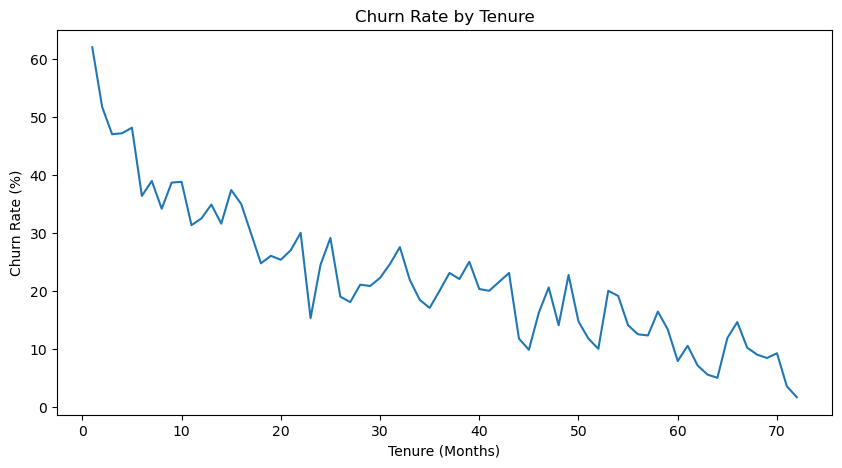

In [11]:
tenure_churn = df.groupby("tenure")["Churn"].mean()*100
tenure_churn = tenure_churn.reset_index()

plt.figure(figsize=(10,5))
plt.plot(tenure_churn["tenure"],tenure_churn["Churn"])
plt.title("Churn Rate by Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Churn Rate (%)")
plt.show()

In [12]:
internet_churn = df.groupby("InternetService")["Churn"].mean().sort_values(ascending=False)*100
internet_churn

InternetService
Fiber optic    41.892765
DSL            18.998344
No              7.434211
Name: Churn, dtype: float64

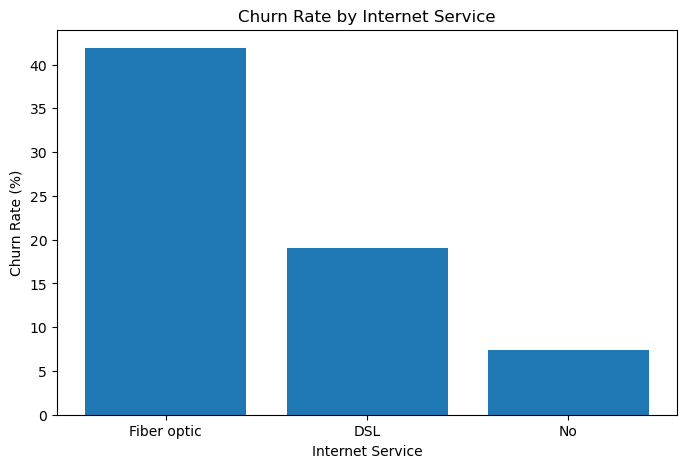

In [17]:
import matplotlib.pyplot as plt
internet_churn = df.groupby("InternetService")["Churn"].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(8,5))
plt.bar(internet_churn.index, internet_churn.values)
plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")
plt.show()          

In [20]:
payment_churn= df.groupby("PaymentMethod")["Churn"].mean().sort_values(ascending=False) * 100
payment_churn                                                                       

PaymentMethod
Electronic check             45.285412
Mailed check                 19.201995
Bank transfer (automatic)    16.731518
Credit card (automatic)      15.253123
Name: Churn, dtype: float64

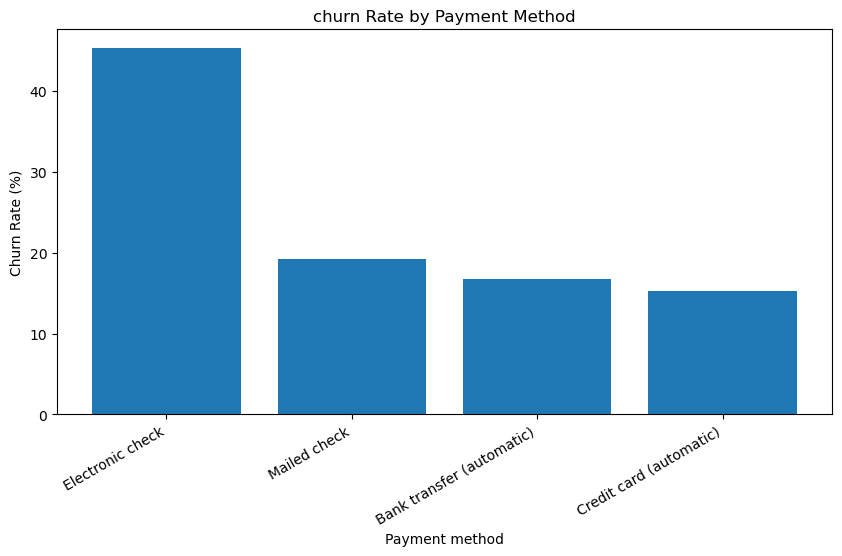

In [21]:
import matplotlib.pyplot as plt

payment_churn = df.groupby("PaymentMethod")["Churn"].mean().sort_values(ascending=False)*100

plt.figure(figsize=(10,5))
plt.bar(payment_churn.index,payment_churn.values)
plt.title("churn Rate by Payment Method")
plt.xlabel("Payment method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=30, ha="right")
plt.show()

In [23]:
df_model=pd.get_dummies(df.drop(columns=["customerID"]),drop_first=True)
df_model.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


In [24]:
x= df_model.drop("Churn", axis=1)
y= df_model["Churn"]

x.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False


In [30]:
df_model=pd.get_dummies(df.drop(columns=["customerID"]),drop_first=True)
X = df_model.drop("Churn",axis=1)
y=df_model["Churn"]

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape)
print(X_test.shape)

(5625, 30)
(1407, 30)


In [32]:
df_model=pd.get_dummies(df.drop(columns=["customerID"]),drop_first=True)
X = df_model.drop("Churn",axis=1)
y=df_model["Churn"]

X.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False


In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    x,y,test_size=0.2, random_state=42,stratify=y
)
print(X_train.shape)
print(X_test.shape)    

(5625, 30)
(1407, 30)


In [36]:
X.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False


In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    x,y,test_size=0.2,random_state=42,stratify=y
)    

In [38]:
print(X.head())

   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  gender_Male  \
0              0       1           29.85         29.85        False   
1              0      34           56.95       1889.50         True   
2              0       2           53.85        108.15         True   
3              0      45           42.30       1840.75         True   
4              0       2           70.70        151.65        False   

   Partner_Yes  Dependents_Yes  PhoneService_Yes  \
0         True           False             False   
1        False           False              True   
2        False           False              True   
3        False           False             False   
4        False           False              True   

   MultipleLines_No phone service  MultipleLines_Yes  ...  \
0                            True              False  ...   
1                           False              False  ...   
2                           False              False  ...   
3               

In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, Y_test=train_test_split(
    x,y,test_size=0.2,random_state=42,stratify=y
)

print(X_train.shape)
print(X_test.shape)

(5625, 30)
(1407, 30)


In [44]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model=LogisticRegression(max_iter=5000)
model.fit(X_train_scaled,y_train)

LogisticRegression(max_iter=5000)

In [47]:
y_pred = model.predict(X_test_scaled)

In [48]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.8038379530916845

In [49]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

y_prob = model.predict_proba(X_test_scaled)[:, 1]
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Confusion Matrix:
 [[916 117]
 [159 215]]

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407

ROC-AUC: 0.8356727976766699


In [50]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(random_state=42, max_depth=4)
tree_model.fit(X_train_scaled, y_train)

DecisionTreeClassifier(max_depth=4, random_state=42)

In [51]:
y_tree_pred = tree_model.predict(X_test_scaled)

from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

print("Confusion Matrix:\n", confusion_matrix(y_test, y_tree_pred))
print("\nClassification Report:\n", classification_report(y_test, y_tree_pred))

y_tree_prob = tree_model.predict_proba(X_test_scaled)[:, 1]
print("ROC-AUC:", roc_auc_score(y_test, y_tree_prob))

## Model Comparison

Logistic Regression performed better than Decision Tree for churn prediction. It achieved higher accuracy, higher recall for churn customers, higher F1-score, and a better ROC-AUC score. Since the business goal is to identify customers at risk of leaving, Logistic Regression was selected as the final model because it caught more churners.



## Final Churn Insight

Logistic Regression was selected as the final model because it performed better than Decision Tree on the churn prediction task. It achieved stronger recall for churn customers, which is important because the business wants to identify as many at-risk customers as possible.

Key takeaway:
- The model is reasonably good at identifying customers likely to churn.
- Customers with shorter tenure, month-to-month contracts, fiber optic internet, and electronic check payment methods appear to be at higher risk.
- The company can use this model to target retention efforts before customers leave.



## Business Recommendations

Based on the churn analysis, the company should:

- Focus on customers with short tenure because they are more likely to leave early.
- Encourage month-to-month customers to move to longer contracts.
- Review fiber optic customers closely, since they may have higher churn risk.
- Investigate electronic check customers, as they appear more likely to churn.
- Use the model to identify at-risk customers and target them with retention offers before they leave.